# Winner Profiles

Goal: instead of predicting individual match outcomes, build a **team-profile** classifier that learns what a World Cup *champion* looks like, then scores any team profile with a probability of being "champion-like".

**Approach**
1. Take every team that played in a World Cup edition (1930-2022), label the eventual champion `1`, everyone else `0`.
2. Attach each team a *pre-tournament* profile: Elo rating/rank and long-run win rate / goal difference, taken from the year **before** that World Cup (no leakage from the tournament itself).
3. Train a classifier on `is_champion` and use it to score arbitrary team profiles (e.g. WC2026 contenders).

**Known limitation**: `elo_ratings_wc2026.csv` only has historical Elo data for the 48 nations relevant to WC2026 qualifying. Italy (4 titles: 1934, 1938, 1982, 2006) isn't in that set, so those four championship editions are dropped from training. This is a real gap, not a bug — there's no other point-in-time ranking source in `data/raw/` going back that far.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, "..")
from src.team_names import normalize

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load raw data

In [2]:
editions = pd.read_csv("../data/raw/wc_all_editions.csv")
matches = pd.read_csv("../data/raw/wc_all_matches.csv")
elo = pd.read_csv("../data/raw/elo_ratings_wc2026.csv")

editions["champion"] = editions["champion"].apply(normalize)
editions["host_list"] = editions["host"].apply(lambda h: [normalize(x.strip()) for x in h.split("/")])
matches["team1"] = matches["team1"].apply(normalize)
matches["team2"] = matches["team2"].apply(normalize)
elo["country"] = elo["country"].apply(normalize)

# Keep the latest snapshot per (country, year) - the file has duplicate rows for some years
elo = elo.sort_values("snapshot_date").drop_duplicates(["country", "year"], keep="last")

editions[["year", "host", "champion"]].tail()

,year,host,champion
17,2006,Germany,Italy
18,2010,South Africa,Spain
19,2014,Brazil,Germany
20,2018,Russia,France
21,2022,Qatar,Argentina


## 2. One row per (edition, participating team), with champion label

In [3]:
rows = []
for year, group in matches.groupby("year"):
    teams = set(group["team1"]) | set(group["team2"])
    edition = editions.loc[editions["year"] == year]
    if edition.empty:
        continue
    champion = edition["champion"].iloc[0]
    host_list = edition["host_list"].iloc[0]
    for team in teams:
        rows.append({
            "year": year,
            "team": team,
            "is_champion": int(team == champion),
            "is_host": int(team in host_list),
        })

participants = pd.DataFrame(rows)
print(f"{len(participants)} team-edition rows across {participants['year'].nunique()} editions")
print(f"{participants['is_champion'].sum()} champion rows (one per covered edition)")

197 team-edition rows across 22 editions
22 champion rows (one per covered edition)


## 3. Attach pre-tournament Elo profile (snapshot from the year *before* the World Cup)

In [4]:
elo_cols = ["rank", "rating", "rank_avg", "rating_avg", "matches_total", "wins", "losses", "draws",
            "goals_for", "goals_against", "confederation"]

def lookup_profile(team: str, before_year: int):
    """Most recent Elo snapshot strictly before `before_year` for `team`."""
    snap = elo[(elo["country"] == team) & (elo["year"] < before_year)]
    if snap.empty:
        return None
    return snap.sort_values("year").iloc[-1][elo_cols]

profile_rows = []
for _, r in participants.iterrows():
    snap = lookup_profile(r["team"], r["year"])
    if snap is None:
        continue
    profile_rows.append({**r.to_dict(), **snap.to_dict()})

profiles = pd.DataFrame(profile_rows)

# Derived ratios instead of raw cumulative counts (career length varies a lot by team/era)
profiles["win_rate"] = profiles["wins"] / profiles["matches_total"].clip(lower=1)
profiles["goal_diff_pg"] = (profiles["goals_for"] - profiles["goals_against"]) / profiles["matches_total"].clip(lower=1)

print(f"{len(profiles)} rows with a usable Elo profile (dropped {len(participants) - len(profiles)} with no Elo history)")
print(f"Champions covered: {profiles['is_champion'].sum()} / {participants['is_champion'].sum()}")
missed = set(participants.loc[participants['is_champion'] == 1, 'team']) - set(profiles.loc[profiles['is_champion'] == 1, 'team'])
print(f"Champions dropped for missing Elo history: {sorted(missed)}")
profiles.head()

145 rows with a usable Elo profile (dropped 52 with no Elo history)
Champions covered: 18 / 22
Champions dropped for missing Elo history: ['Italy']


,year,team,is_champion,is_host,rank,rating,rank_avg,rating_avg,matches_total,wins,losses,draws,goals_for,goals_against,confederation,win_rate,goal_diff_pg
0,1930,United States,0,0,21,1672,18,1697,12,5,5,2,28,32,CONCACAF,0.416667,-0.333333
1,1930,Mexico,0,0,27,1613,21,1681,8,4,3,1,17,20,CONCACAF,0.500000,-0.375000
2,1930,Brazil,0,0,7,1923,8,1885,39,16,15,8,63,58,CONMEBOL,0.410256,0.128205
3,1930,Argentina,0,0,1,2081,3,1972,179,88,49,42,346,217,CONMEBOL,0.491620,0.720670
4,1930,Belgium,0,0,23,1648,12,1778,117,43,56,18,238,287,UEFA,0.367521,-0.418803


## 4. Champion vs. non-champion profiles

In [5]:
feature_cols = ["rank", "rating", "rank_avg", "rating_avg", "win_rate", "goal_diff_pg", "is_host"]
profiles.groupby("is_champion")[feature_cols].mean()

,rank,rating,rank_avg,rating_avg,win_rate,goal_diff_pg,is_host
is_champion,,,,,,,
0,13.913386,1886.464567,18.448819,1807.307087,0.491820,0.565996,0.062992
1,6.000000,1979.555556,7.833333,1911.500000,0.543038,0.879556,0.277778


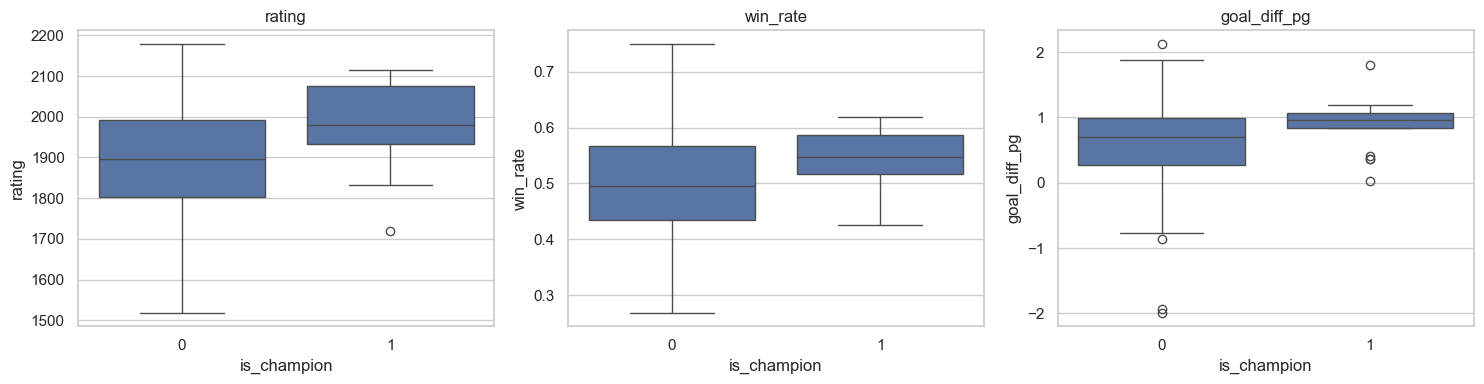

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["rating", "win_rate", "goal_diff_pg"]):
    sns.boxplot(data=profiles, x="is_champion", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()

## 5. Model: P(champion-like) from a team profile

Champions are ~15% of rows, so we use `class_weight="balanced"` and evaluate with stratified CV (the dataset is too small for a held-out test split to be reliable on its own).

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score

numeric_cols = ["rank", "rating", "rank_avg", "rating_avg", "win_rate", "goal_diff_pg"]
categorical_cols = ["confederation"]
binary_cols = ["is_host"]

X = profiles[numeric_cols + categorical_cols + binary_cols]
y = profiles["is_champion"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("bin", "passthrough", binary_cols),
])

models = {
    "logreg": Pipeline([("prep", preprocess), ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))]),
    "rf": Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=300, max_depth=4, class_weight="balanced", random_state=42))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, pipe in models.items():
    proba = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    print(f"{name:8s}  ROC-AUC={roc_auc_score(y, proba):.3f}  "
          f"AvgPrecision={average_precision_score(y, proba):.3f}  "
          f"Brier={brier_score_loss(y, proba):.3f}")

logreg    ROC-AUC=0.719  AvgPrecision=0.244  Brier=0.197
rf        ROC-AUC=0.623  AvgPrecision=0.161  Brier=0.147


Pick the better-performing model above, refit it on the full dataset, and inspect what drives the prediction.

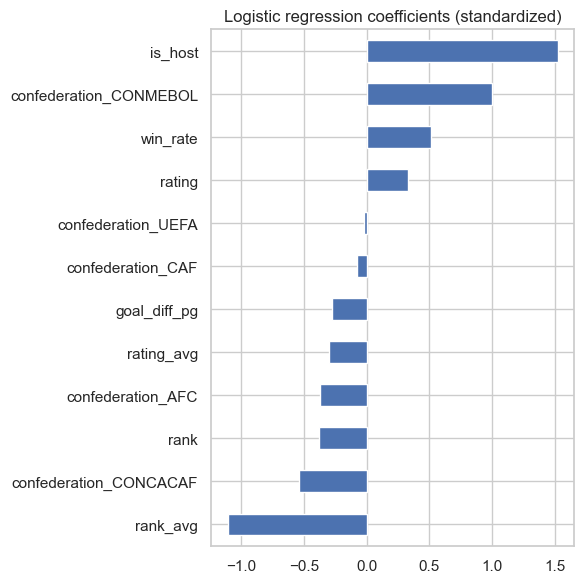

In [8]:
final_model = models["logreg"]
final_model.fit(X, y)

feature_names = (numeric_cols
                  + list(final_model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_cols))
                  + binary_cols)
coefs = pd.Series(final_model.named_steps["clf"].coef_[0], index=feature_names).sort_values()
coefs.plot(kind="barh", figsize=(6, 6), title="Logistic regression coefficients (standardized)")
plt.tight_layout()

## 6. Compare any team profile against historical winners

In [9]:
def predict_winner_probability(profile: dict, model=final_model) -> float:
    """
    profile must contain: rank, rating, rank_avg, rating_avg, win_rate,
    goal_diff_pg, confederation, is_host
    """
    row = pd.DataFrame([profile])[numeric_cols + categorical_cols + binary_cols]
    return float(model.predict_proba(row)[0, 1])


def team_profile_for_year(team: str, as_of_year: int, is_host: bool = False) -> dict:
    """Build a profile dict for `team` from the latest Elo snapshot strictly before `as_of_year`."""
    snap = lookup_profile(normalize(team), as_of_year)
    if snap is None:
        raise ValueError(f"No Elo history for {team} before {as_of_year}")
    return {
        "rank": snap["rank"],
        "rating": snap["rating"],
        "rank_avg": snap["rank_avg"],
        "rating_avg": snap["rating_avg"],
        "win_rate": snap["wins"] / max(snap["matches_total"], 1),
        "goal_diff_pg": (snap["goals_for"] - snap["goals_against"]) / max(snap["matches_total"], 1),
        "confederation": snap["confederation"],
        "is_host": int(is_host),
    }


# Sanity check: 2022 champion should score relatively high
predict_winner_probability(team_profile_for_year("Argentina", 2022))
predict_winner_probability(team_profile_for_year("Belgium", 2018))

0.17398368828517097

## 7. Demo: rank WC2026 contenders by "winner-likeness"

In [10]:
wc2026_hosts = {"USA", "Mexico", "Canada"}
latest_year = elo["year"].max() + 1  # use the most recent available snapshot

candidates = sorted(elo.loc[elo["year"] == elo["year"].max(), "country"].unique())
results = []
for team in candidates:
    is_host = team in {normalize(h) for h in wc2026_hosts}
    try:
        profile = team_profile_for_year(team, latest_year, is_host=is_host)
    except ValueError:
        continue
    results.append({"team": team, "is_host": is_host, "winner_probability": predict_winner_probability(profile)})

leaderboard = pd.DataFrame(results).sort_values("winner_probability", ascending=False).reset_index(drop=True)
leaderboard.head(48)

,team,is_host,winner_probability
0,Argentina,False,0.777013
1,Brazil,False,0.768104
2,Spain,False,0.610004
3,England,False,0.510184
4,Uruguay,False,0.438590
5,France,False,0.433012
6,Germany,False,0.397733
7,Mexico,True,0.373361
8,Croatia,False,0.326317
9,Netherlands,False,0.305992


## Notes / next steps

- Sample size is small (~18 usable editions, ~120 team-edition rows, ~15 positives) — treat the probabilities as a relative ranking signal, not a precise calibrated forecast.
- Italy's four titles are excluded because `elo_ratings_wc2026.csv` doesn't cover them. If a fuller historical ranking source becomes available, re-run this notebook to recover those rows.
- `win_rate` / `goal_diff_pg` are *career-cumulative* (all-time up to that year), not recent form — there's no historical match-by-match log far enough back to compute rolling form pre-1990s.
- This model is intentionally separate from the match-level home/away/draw classifier in `training_model.ipynb` — it answers "does this team's overall profile look like a champion's?", not "who wins this specific match?".